# Mini Project 9 - Part 1: Data Exploration & Preprocessing
## Content Moderation with Transformers

**Team Members:** [Your names here]

**Dataset:** Twitter Hate Speech and Offensive Language (Davidson et al., 2017)

---

### Objectives
1. Load and explore the dataset
2. Analyze class distribution and imbalance
3. Clean and preprocess text
4. Create stratified train/val/test splits
5. Visualize examples from each class

In [32]:
# Install required packages (run in Colab)
# !pip install transformers datasets torch scikit-learn matplotlib seaborn pandas numpy tqdm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

✅ Data directory ready!


## 1. Load Dataset

Download from: https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv

In [34]:
# Download dataset
url = 'https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv'
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (24783, 7)

Columns: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [35]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nDataset info:")
df.info()

Missing values:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          24783 non-null  int64
 1   count               24783 non-null  int64
 2   hate_speech         24783 non-null  int64
 3   offensive_language  24783 non-null  int64
 4   neither             24783 non-null  int64
 5   class               24783 non-null  int64
 6   tweet               24783 non-null  str  
dtypes: int64(6), str(1)
memory usage: 1.3 MB


## 2. Class Distribution Analysis

Classes:
- **0**: Hate speech
- **1**: Offensive language
- **2**: Neither

In [36]:
# Class distribution
class_counts = df['class'].value_counts().sort_index()
class_percentages = (class_counts / len(df) * 100).round(2)

print("Class Distribution:")
print("-" * 50)
for cls, count in class_counts.items():
    label = {0: 'Hate speech', 1: 'Offensive', 2: 'Neither'}[cls]
    pct = class_percentages[cls]
    print(f"{cls} ({label:15s}): {count:5d} samples ({pct:5.2f}%)")

print(f"\nTotal samples: {len(df)}")

Class Distribution:
--------------------------------------------------
0 (Hate speech    ):  1430 samples ( 5.77%)
1 (Offensive      ): 19190 samples (77.43%)
2 (Neither        ):  4163 samples (16.80%)

Total samples: 24783


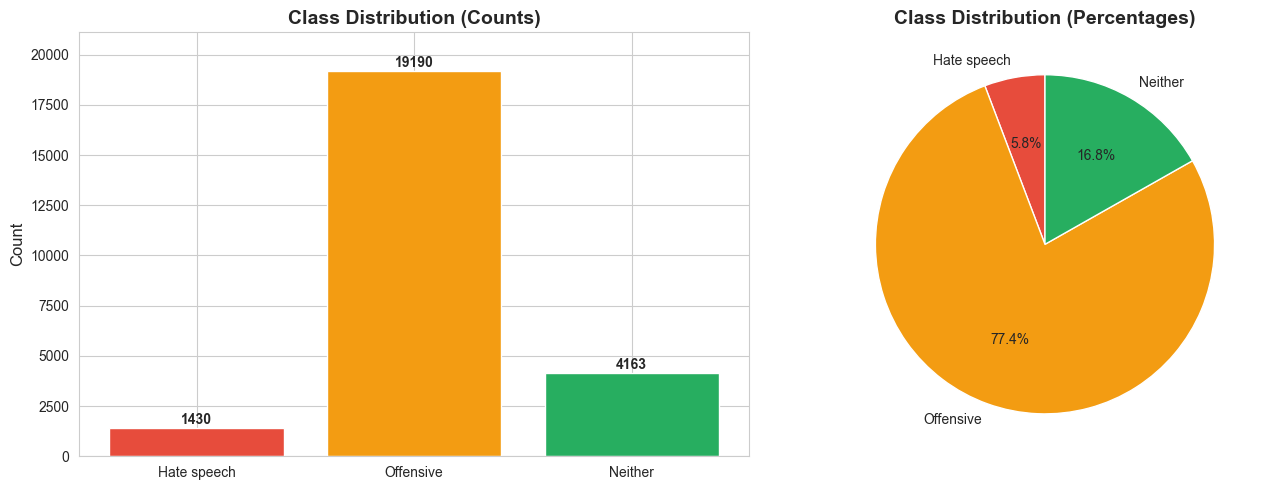


⚠️ IMBALANCE DETECTED:
   - Majority class (Offensive): 77.43%
   - Minority class (Hate): 5.77%
   - Imbalance ratio: 13.4:1

   We'll need to handle this with weighted loss or resampling!


In [37]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_names = ['Hate speech', 'Offensive', 'Neither']
axes[0].bar(class_names, class_counts.values, color=['#e74c3c', '#f39c12', '#27ae60'])
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values) * 1.1)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_names, autopct='%1.1f%%',
            colors=['#e74c3c', '#f39c12', '#27ae60'], startangle=90)
axes[1].set_title('Class Distribution (Percentages)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️ IMBALANCE DETECTED:")
print(f"   - Majority class (Offensive): {class_percentages[1]}%")
print(f"   - Minority class (Hate): {class_percentages[0]}%")
print(f"   - Imbalance ratio: {class_counts[1] / class_counts[0]:.1f}:1")
print("\n   We'll need to handle this with weighted loss or resampling!")

## 3. Text Length Analysis

In [38]:
# Calculate text lengths
df['text_length'] = df['tweet'].str.len()
df['word_count'] = df['tweet'].str.split().str.len()

# Statistics
print("Text Length Statistics:")
print("-" * 50)
print(df[['text_length', 'word_count']].describe())

# By class
print("\nAverage text length by class:")
for cls in [0, 1, 2]:
    label = {0: 'Hate speech', 1: 'Offensive', 2: 'Neither'}[cls]
    avg_len = df[df['class'] == cls]['text_length'].mean()
    avg_words = df[df['class'] == cls]['word_count'].mean()
    print(f"  {label:15s}: {avg_len:.1f} chars, {avg_words:.1f} words")

Text Length Statistics:
--------------------------------------------------
        text_length    word_count
count  24783.000000  24783.000000
mean      85.436065     14.117016
std       41.548238      6.825525
min        5.000000      1.000000
25%       52.000000      9.000000
50%       81.000000     13.000000
75%      119.000000     19.000000
max      754.000000     52.000000

Average text length by class:
  Hate speech    : 84.6 chars, 13.9 words
  Offensive      : 83.5 chars, 14.0 words
  Neither        : 94.9 chars, 14.9 words


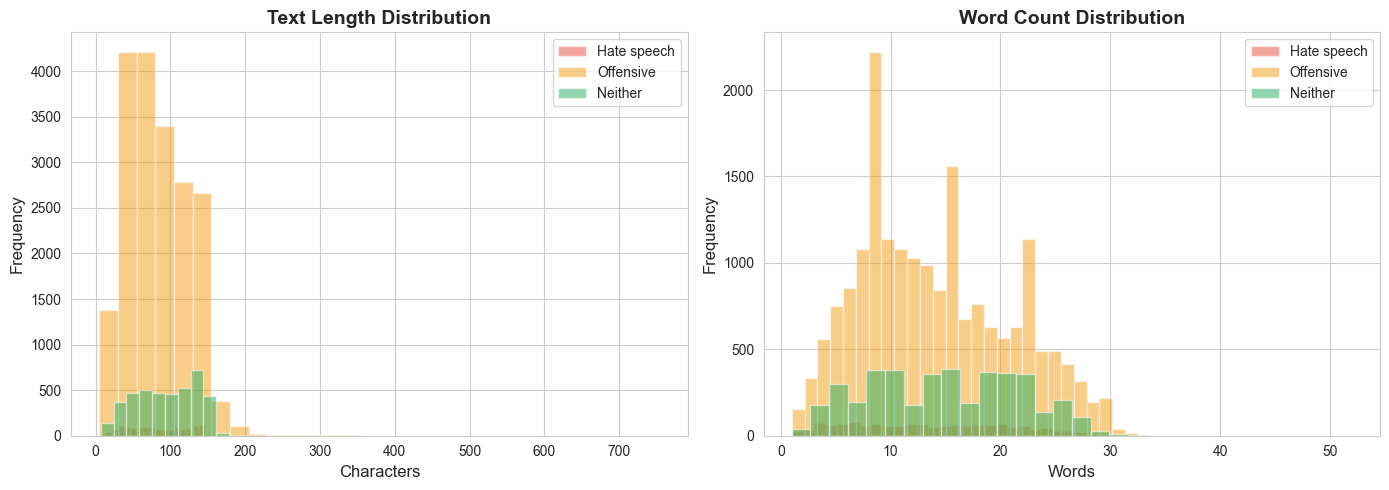

In [39]:
# Visualize text lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color in zip([0, 1, 2], ['#e74c3c', '#f39c12', '#27ae60']):
    label = {0: 'Hate speech', 1: 'Offensive', 2: 'Neither'}[cls]
    data = df[df['class'] == cls]['text_length']
    axes[0].hist(data, bins=30, alpha=0.5, label=label, color=color)
    axes[1].hist(df[df['class'] == cls]['word_count'], bins=30, alpha=0.5, label=label, color=color)

axes[0].set_xlabel('Characters', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend()

axes[1].set_xlabel('Words', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Text Cleaning Functions

Tweets contain:
- URLs
- @mentions
- Hashtags
- Special characters
- Emoji (we'll keep these for transformers, remove for TF-IDF)

In [40]:
def clean_text_basic(text):
    """
    Basic cleaning for transformers (keep most structure).
    - Remove URLs
    - Keep @mentions and hashtags (they have meaning)
    - Remove extra whitespace
    """
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_aggressive(text):
    """
    Aggressive cleaning for TF-IDF baseline.
    - Remove URLs, mentions, hashtags
    - Lowercase
    - Remove special characters
    """
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove @mentions and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    # Remove special characters (keep letters, numbers, spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test both cleaning functions
sample_tweet = df['tweet'].iloc[0]
print("Original:")
print(f"  {sample_tweet}")
print("\nBasic cleaning (for transformers):")
print(f"  {clean_text_basic(sample_tweet)}")
print("\nAggressive cleaning (for TF-IDF):")
print(f"  {clean_text_aggressive(sample_tweet)}")

Original:
  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...

Basic cleaning (for transformers):
  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...

Aggressive cleaning (for TF-IDF):
  rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out


In [41]:
# Apply basic cleaning (we'll use this for transformers)
df['text_clean'] = df['tweet'].apply(clean_text_basic)

# Also create aggressively cleaned version (for TF-IDF baseline)
df['text_clean_aggressive'] = df['tweet'].apply(clean_text_aggressive)

print("Cleaning complete!")
print(f"Original column: 'tweet'")
print(f"Basic clean: 'text_clean' (for transformers)")
print(f"Aggressive clean: 'text_clean_aggressive' (for TF-IDF)")

Cleaning complete!
Original column: 'tweet'
Basic clean: 'text_clean' (for transformers)
Aggressive clean: 'text_clean_aggressive' (for TF-IDF)


## 5. Show Examples from Each Class

⚠️ **Content Warning:** The following examples contain offensive and hateful language.

In [42]:
# Sample 5 examples from each class
for cls in [0, 1, 2]:
    label = {0: 'HATE SPEECH', 1: 'OFFENSIVE LANGUAGE', 2: 'NEITHER'}[cls]
    color = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}[cls]
    
    print("\n" + "="*70)
    print(f"CLASS {cls}: {label}")
    print("="*70)
    
    samples = df[df['class'] == cls].sample(5, random_state=SEED)
    
    for idx, (i, row) in enumerate(samples.iterrows(), 1):
        print(f"\nExample {idx}:")
        print(f"  {row['text_clean']}")
        print(f"  (Length: {row['text_length']} chars)")


CLASS 0: HATE SPEECH

Example 1:
  @AustinG1135 I do not like talking to you faggot and I did but in a nicely way fag
  (Length: 82 chars)

Example 2:
  RT @mitchmancuso: @BrantPrintup:What straight guys take a picture of themselves naked in a hot tun.What fags @jakesiwy @Ryan_Murphy3 @Randy&#8230;
  (Length: 146 chars)

Example 3:
  @clinchmtn316 @sixonesixband AMERICA today, the rule of thumb is: when in doubt, blame "whitey"
  (Length: 95 chars)

Example 4:
  @STACCS_WNT_FOLD you tell me, coon.
  (Length: 35 chars)

Example 5:
  RT @FAAMMoverALL: This nigguh Chris Paul
  (Length: 40 chars)

CLASS 1: OFFENSIVE LANGUAGE

Example 1:
  Why is it everytime I go to cracker barrel the girl with great tits that seats you who is your waitress nope its the chick with 2 teeth
  (Length: 135 chars)

Example 2:
  Run that nigga, you don't want that nigga, but I need a bad bitch that's hotter than me
  (Length: 87 chars)

Example 3:
  I need a girl from Jamaica I can't fuck with these basic blac

## 6. Key Observations

### What makes this dataset challenging?

Write your observations here after reviewing the examples:

1. **Class imbalance**: 
   - [Your observation]

2. **Hate speech vs offensive language**:
   - [How are they different? How are they similar?]

3. **Language characteristics**:
   - [Slang, abbreviations, spelling variations, etc.]

4. **Potential annotation issues**:
   - [Do you notice any examples that might be mislabeled?]

## 7. Create Train/Val/Test Splits

Using stratified split to preserve class distribution.

In [43]:
from sklearn.model_selection import train_test_split

# First split: 80% train+val, 20% test
train_val, test = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['class'], 
    random_state=SEED
)

# Second split: 80% train, 20% val (from train_val)
train, val = train_test_split(
    train_val, 
    test_size=0.2, 
    stratify=train_val['class'], 
    random_state=SEED
)

print("Split sizes:")
print(f"  Train: {len(train):5d} ({len(train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val):5d} ({len(val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test):5d} ({len(test)/len(df)*100:.1f}%)")
print(f"  Total: {len(df):5d}")

Split sizes:
  Train: 15860 (64.0%)
  Val:    3966 (16.0%)
  Test:   4957 (20.0%)
  Total: 24783


In [44]:
# Verify stratification
print("\nClass distribution in each split:")
print("-" * 70)
print(f"{'Split':<10} {'Hate (0)':<15} {'Offensive (1)':<15} {'Neither (2)':<15}")
print("-" * 70)

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    dist = split['class'].value_counts(normalize=True).sort_index() * 100
    print(f"{name:<10} {dist[0]:>6.2f}%        {dist[1]:>6.2f}%        {dist[2]:>6.2f}%")

print("\n✅ Stratification successful - class ratios preserved across all splits!")


Class distribution in each split:
----------------------------------------------------------------------
Split      Hate (0)        Offensive (1)   Neither (2)    
----------------------------------------------------------------------
Train        5.77%         77.43%         16.80%
Val          5.77%         77.43%         16.79%
Test         5.77%         77.43%         16.80%

✅ Stratification successful - class ratios preserved across all splits!


## 8. Save Processed Data

In [45]:
# Save splits for use in other notebooks
train.to_csv('data/train.csv', index=False)
val.to_csv('data/val.csv', index=False)
test.to_csv('data/test.csv', index=False)

print("Saved splits to:")
print("  ../data/train.csv")
print("  ../data/val.csv")
print("  ../data/test.csv")
print("\n✅ Data exploration complete! Ready for modeling.")

Saved splits to:
  ../data/train.csv
  ../data/val.csv
  ../data/test.csv

✅ Data exploration complete! Ready for modeling.


---

## Summary

**Dataset Statistics:**
- Total samples: ~25,000
- Classes: 3 (hate speech, offensive, neither)
- **Severe class imbalance**: ~5% hate, ~77% offensive, ~18% neither
- Average length: ~100-140 characters

**Key Challenges:**
1. Class imbalance (will need weighted loss)
2. Distinguishing hate speech from offensive language (subtle)
3. Noisy text (slang, abbreviations, misspellings)
4. Context-dependent meaning

**Next Steps:**
- Notebook 2: Build TF-IDF baseline
- Notebook 3: Fine-tune DistilBERT transformer